#1. Importación de librerías y bancos de datos.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

response = requests.get(url)

df_master = pd.read_json(url)
df_master.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#2. Limpieza y Transformación de Datos

In [7]:
columnas_anidadas = ['customer', 'phone', 'internet', 'account']

df_master = df_master.copy()

for col in columnas_anidadas:
    df_temp = pd.json_normalize(df_master[col])
    df_master = pd.concat([df_master, df_temp], axis=1)

print(f'Nuevas dimensiones del DataFrame: {df_master.shape}')
df_master.head()

Nuevas dimensiones del DataFrame: (7267, 25)


,customerID,Churn,customer,phone,internet,account,gender,SeniorCitizen,Partner,Dependents,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,Yes,Yes,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,1,Yes,No,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Female,1,Yes,No,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
df_limpio = df_master.drop(columns=columnas_anidadas)


print("Estructura final de columnas:")
df_limpio.info()

Estructura final de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract    

In [9]:
# 1. Identificamos las columnas que tienen valores 'Yes' y 'No'
cols_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService',
                 'PaperlessBilling', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

# 2. Aplicamos la transformación: 'Yes' -> 1, 'No' -> 0
for col in cols_binarias:
    df_limpio[col] = df_limpio[col].map({'Yes': 1, 'No': 0})

# 3. Revisamos el resultado con un head
print("Verificación de transformación binaria (1=Yes, 0=No):")
df_limpio[cols_binarias].head()

Verificación de transformación binaria (1=Yes, 0=No):


,Churn,Partner,Dependents,PhoneService,PaperlessBilling,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0.0,1,1,1,1,1.0,0.0,1.0,1.0,0.0
1,0.0,0,0,1,0,0.0,0.0,0.0,0.0,1.0
2,1.0,0,0,1,1,0.0,1.0,0.0,0.0,0.0
3,1.0,1,0,1,1,1.0,1.0,0.0,1.0,1.0
4,1.0,1,0,1,1,0.0,0.0,1.0,1.0,0.0


In [10]:
# Llenamos los nulos resultantes con 0 para asegurar que todo sea numérico
df_limpio[cols_binarias] = df_limpio[cols_binarias].fillna(0)

# Verificamos de nuevo
df_limpio[cols_binarias].head()

,Churn,Partner,Dependents,PhoneService,PaperlessBilling,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0.0,1,1,1,1,1.0,0.0,1.0,1.0,0.0
1,0.0,0,0,1,0,0.0,0.0,0.0,0.0,1.0
2,1.0,0,0,1,1,0.0,1.0,0.0,0.0,0.0
3,1.0,1,0,1,1,1.0,1.0,0.0,1.0,1.0
4,1.0,1,0,1,1,0.0,0.0,1.0,1.0,0.0


In [11]:
## --- Columna de cuentas diarias ---

# Calculamos el costo diario dividiendo el cargo mensual entre 30 días
df_limpio['Cuentas_Diarias'] = (df_limpio['Charges.Monthly'] / 30).round(2)

# Verificamos la creación de la columna con las métricas de cargos
print("Cálculo de cuentas diarias finalizado:")
df_limpio[['Charges.Monthly', 'Cuentas_Diarias']].head()

Cálculo de cuentas diarias finalizado:


,Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [23]:
# 'coerce' convertirá cualquier espacio en blanco o texto extraño en NaN (nulo real)
df_limpio['Charges.Total'] = pd.to_numeric(df_limpio['Charges.Total'], errors='coerce')

# 2. Ahora que son NaN reales, los llenamos con 0 para no perder filas
df_limpio['Charges.Total'] = df_limpio['Charges.Total'].fillna(0)

# 3. Verificamos que ahora sí sea un número (debe decir float64)
print(f"Tipo de dato actual de Charges.Total: {df_limpio['Charges.Total'].dtype}")

Tipo de dato actual de Charges.Total: float64


#3. Carga y Análisis.

In [12]:
#Seleccionamos las columnas numéricas clave para el análisis
cols_analisis = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

# Generamos el resumen estadístico descriptivo
resumen_estadistico = df_limpio[cols_analisis].describe()

# Personalizamos la salida para que sea más legible
print("Métricas Estadísticas del Dataset:")
resumen_estadistico.loc[['mean', '50%', 'std', 'min', 'max']]

Métricas Estadísticas del Dataset:


,tenure,Charges.Monthly,Cuentas_Diarias
mean,32.346498,64.720098,2.157292
50%,29.000000,70.300000,2.340000
std,24.571773,30.129572,1.004407
min,0.000000,18.250000,0.610000
max,72.000000,118.750000,3.960000


In [13]:
print("\nPlan mensual más frecuente (Moda):")
print(df_limpio['Charges.Monthly'].mode()[0])


Plan mensual más frecuente (Moda):
20.05


In [14]:
## --- Analisis Descriptivo ---

# 1. Definimos las columnas numéricas de interés
columnas_analisis = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

# 2. Generamos el resumen estadístico descriptivo
resumen = df_limpio[columnas_analisis].describe()

# 3. Mostramos: Media (mean), Mediana (50%), Desviación Estándar (std), Mínimo y Máximo.
resumen_final = resumen.loc[['mean', '50%', 'std', 'min', 'max']]

print("Resumen Estadístico del Rendimiento de Clientes:")
resumen_final

Resumen Estadístico del Rendimiento de Clientes:


,tenure,Charges.Monthly,Cuentas_Diarias
mean,32.346498,64.720098,2.157292
50%,29.000000,70.300000,2.340000
std,24.571773,30.129572,1.004407
min,0.000000,18.250000,0.610000
max,72.000000,118.750000,3.960000


In [15]:
print("Proporción de clientes que permanecen vs. los que se dan de baja:")
df_limpio['Churn'].value_counts(normalize=True) * 100

Proporción de clientes que permanecen vs. los que se dan de baja:


,proportion
Churn,
0.0,74.280996
1.0,25.719004


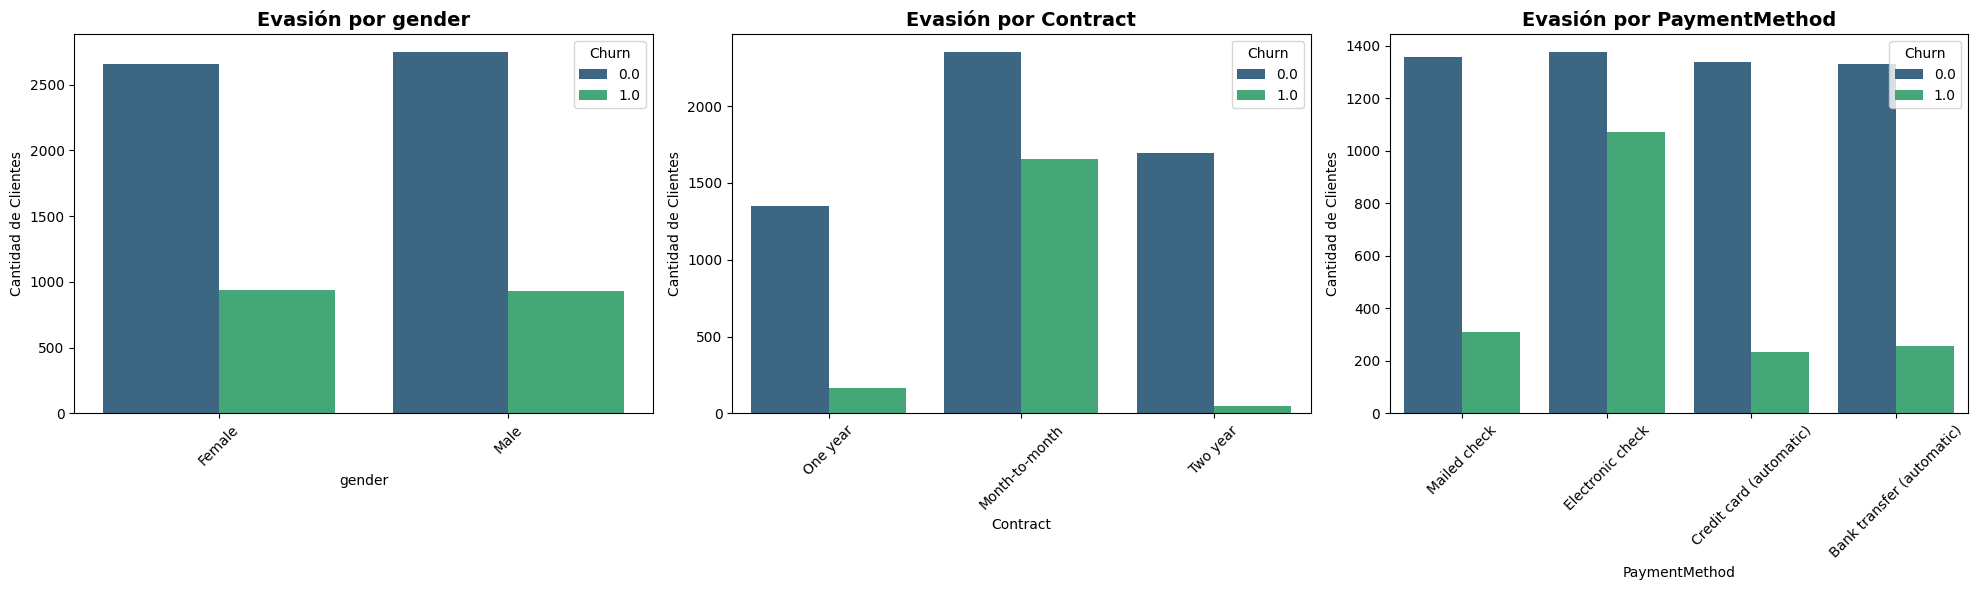

In [16]:
## --- Recuento de evasión por varibles categóricas ---

# Definimos las variables categóricas que queremos explorar
variables_perfil = ['gender', 'Contract', 'PaymentMethod']

plt.figure(figsize=(20, 6))

for i, col in enumerate(variables_perfil):
    plt.subplot(1, 3, i+1)
    # Creamos un gráfico de recuento comparativo
    sns.countplot(data=df_limpio, x=col, hue='Churn', palette='viridis')

    plt.title(f'Evasión por {col}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

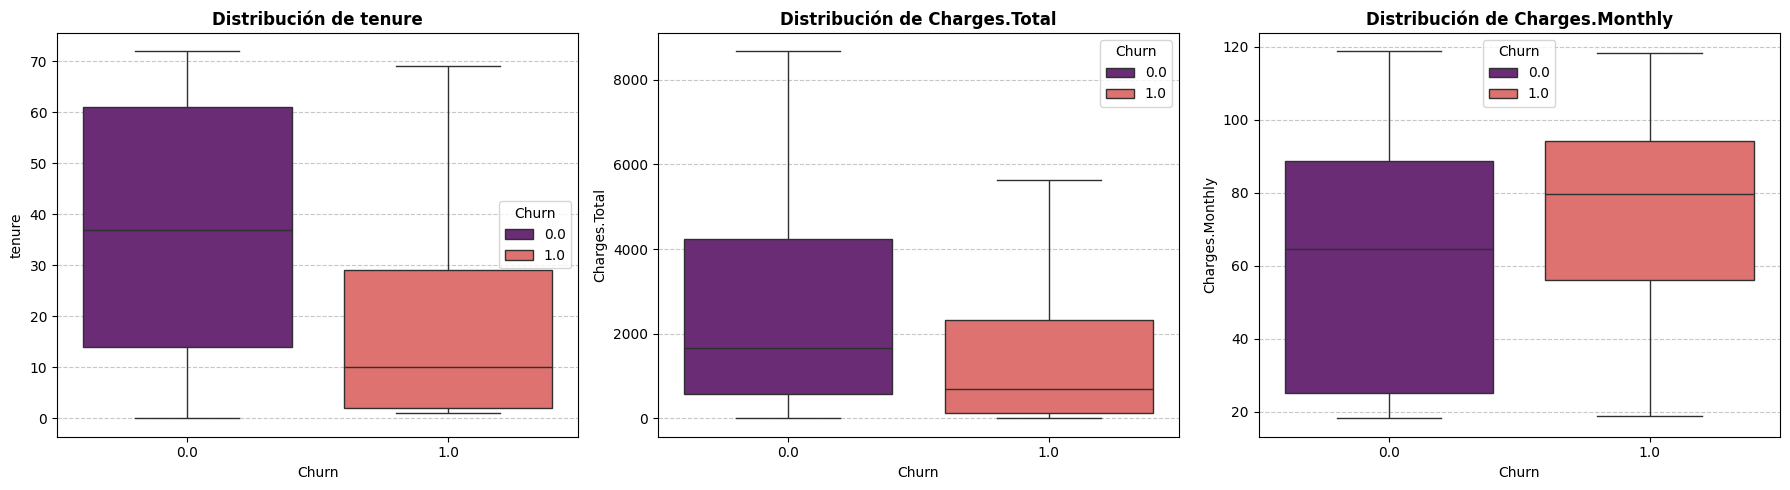

In [22]:
# Definimos las variables numéricas
vars_numericas = ['tenure', 'Charges.Total', 'Charges.Monthly']

plt.figure(figsize=(18, 5))

for i, col in enumerate(vars_numericas):
    plt.subplot(1, 3, i+1)

    # Usamos boxplot optimizado
    sns.boxplot(data=df_limpio, x='Churn', y=col, hue='Churn', palette='magma', showfliers=False)

    plt.title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Informe Final: Análisis de Evasión de Clientes

### Introducción.
El siguiente anaáisis tiene como principal objetivo comprender el comportamiento
de los clientes de la empresa de Telecom X, tomando como principal punto de enfoque el problema de la **evasión (churn)**. Buscamos identificar qué factores demográficos, de servicio o financieros influyen en la decisión de un cliente al cancelar su suscripción, para así poder tomar decisiones estratégicas fundamentadas.

### Limpieza y tratamientos de datos.
Para garantizar la calidad del análisis, primero se realizó un proceso de ETL que incluyo:
* Desempaquetado: Se aplanaron estructuras anidadas en formato JSON para convertirlas en columnas tabulares.
* Estandarización: Se transformaron variables categóricas de texto (Yes/No) a formato binario (1/0) para facilitar el modelado estadístico.
* Correción de tipos de datos: Se realizó la conversión de métricas financieras a valores numéricos flotantes, tratando los espacios vacíos y valores nulos para evitar sesgos en el análisis.
* Creación de nuevas variables: Se calculó una nueva métrica de `Cuentas_Diarias` para tener un nivel de detalle más preciso sobre el gasto real de cada cliente.

### Análisis Exploratorio de Datos (EDA).
Para comprender mejor la situación, se crearon diferentes gráficos que nos permiten compara a los clientes que se quedan con los que deciden cancelar. Revisamos perfiles básicos como el género, el tipo de contrato y la forma de pago. Y los cruzamos con sus datos de consumo (cuánto tiempo llevan con la empresa, cuánto pagan al mes y cuánto han gastado en total).

### Conclusiones e Insights.
A partir de las visualizaciones generadas, se identificaron los siguientes patrones críticos de evasión:
* Los primeros meses son críticos, la gran mayoria de las cancelaciones ocurren al poco tiempo de haber contratado el servicio.
* El precio mensual es un factor de peso, notamos que los clientes que deciden irse suelen tener mensualidades más altas que el promedio de los clientes leales.
* Los contratos "mes a mes" son riesgosos, las personas que pagan su servicio mes a mes, sin un compromiso a largo plazo, son las que más cancelan.

### Recomendaciones Estratégicas.
Para evitar que más clientes se vayan y mejorar la retención, se sugieren las siguientes acciones:
* Fomentar contratos a largo plazo, ofrecer promociones, descuentos o beneficios extra a los clientes que estan "mes a mes" para convencerlos de cambiar a un plan de uno o dos años.
* Cuidar mucho a los clientes nuevos, como la mayoría de las bajas suceden al principio, es vital crecar un programa de bienvenida o seguimiento durante los primeros 9' días para asegurar que el cliente esté fleiz y entienda todo el valor del servicio.
* Revisar los paquetes más caros, se necesita investigar por qué los clientes que pagan más son los que más se van. Valdría la pena revisar si estos paquetes premium necesitan mejores beneficios para que el cliente sienta que el precio realmente lo vale.

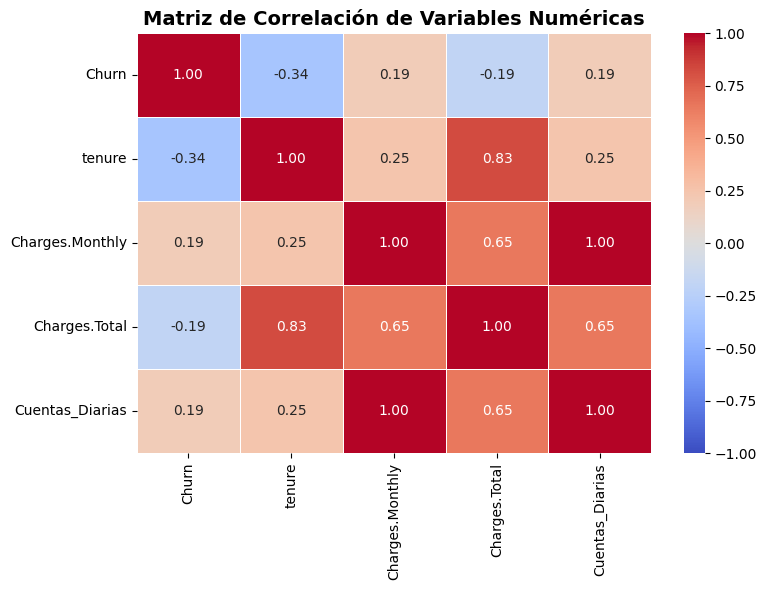

In [25]:
# --- Bonus: Mapa de Calor de Correlaciones ---

# 1. Seleccionamos solo las columnas numéricas relevantes, incluyendo Churn y la cuenta diaria
cols_correlacion = ['Churn', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

# 2. Calculo de la matriz de correlación de Pandas
matriz_corr = df_limpio[cols_correlacion].corr()

# 3. Graficamos usando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Descubrimientos en la matriz anterior.

* Churn vs tenure (-0.34): Es el cuadro más azul de la primera fila. Al ser un número negativo, confirma matemáticamente el hallazgo clave: a mayor tiempo (tenure), menor es el abandono (Churn).

* Churn vs Charges.Monthly (0.19) y Cuentas_Diarias (0.19): Tienen un tono rojizo suave. Al ser números positivos, indican que a medida que sube el cobro mensual (o diario), la probabilidad de evasión también sube ligeramente. ¡Confirma que los clientes son sensibles a los precios altos!

* Tenure vs Charges.Total (0.83): Es un rojo muy intenso. Es una relación muy fuerte y lógica: mientras más meses se quede el cliente, mayor será la suma total de dinero que le ha pagado a la empresa a lo largo de su vida útil.
